In [3]:
import pyvinecopulib as pv
import numpy as np
import pandas as pd

In [42]:
df = pd.read_csv("../data/hurricaneexposuredata/lee_annual_rainmax_with_wind_duration.csv")
df.head()

,storm_id,year,fips,county,tot_precip,vmax_sust,vmax_gust,storm_dist,closest_date,local_time,closest_time_utc,sust_dur,gust_dur,usa_atcf_id
0,Beryl-1988,1988,12071,Lee,51.4,1.752579,2.611343,772.858972,1988-08-08,1988-08-08T19:00:00Z,1988-08-08T23:00:00Z,0,0,AL021988
1,Chantal-1989,1989,12071,Lee,38.3,1.067318,1.590303,900.962153,1989-07-30,1989-07-30T18:45:00Z,1989-07-30T22:45:00Z,0,0,AL041989
2,Marco-1990,1990,12071,Lee,39.1,20.205249,30.105821,72.983918,1990-10-11,1990-10-11T00:45:00Z,1990-10-11T04:45:00Z,75,1065,AL151990
3,Ana-1991,1991,12071,Lee,99.5,8.785912,13.091008,31.666725,1991-06-30,1991-06-30T10:15:00Z,1991-06-30T14:15:00Z,0,0,AL011991
4,AL02-1992,1992,12071,Lee,163.4,7.090226,10.564437,228.091478,1992-06-26,1992-06-26T05:45:00Z,1992-06-26T09:45:00Z,0,0,AL021992


In [43]:
df.shape

(31, 14)

In [44]:
df[["tot_precip", "vmax_gust", "gust_dur"]].describe().round(2)

,tot_precip,vmax_gust,gust_dur
count,24.00,31.00,31.00
mean,71.65,15.67,173.23
std,38.72,16.37,392.16
min,16.50,1.27,0.00
25%,39.10,4.47,0.00
50%,68.80,11.46,0.00
75%,98.42,19.40,0.00
max,163.40,78.62,1650.00


## Fit a model

(<Figure size 840x840 with 9 Axes>,
 array([[<Axes: ylabel='var1'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='var2'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='var1', ylabel='var3'>, <Axes: xlabel='var2'>,
         <Axes: xlabel='var3'>]], dtype=object))

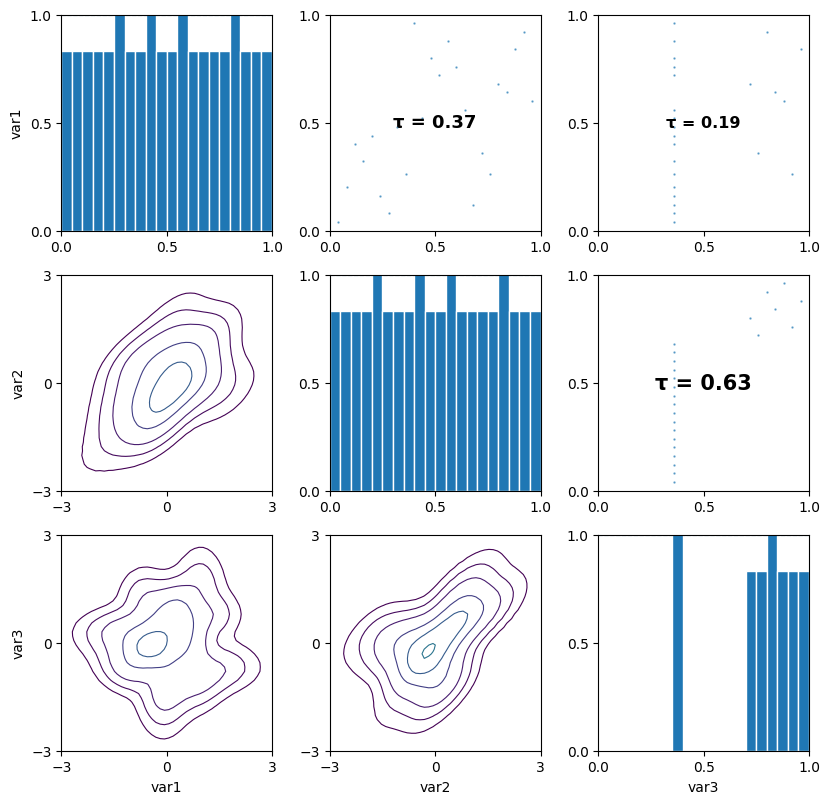

In [94]:
d = 3 # the dimension
vars_ = ["tot_precip", "vmax_gust", "gust_dur"]

x_df = (
    df[vars_]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

x = x_df.to_numpy()
d = x.shape[1]

# pseudo-observations
u = pv.to_pseudo_obs(x)

pv.pairs_copula_data(u, scatter_size=0.5)

In [95]:
# fit vine copula
cop = pv.Vinecop.from_data(u)
print(cop)

<pyvinecopulib.Vinecop> Vinecop model with 3 variables
tree edge conditioned variables conditioning variables var_types       family rotation parameters  df  tau 
   1    1                  1, 2                             c, c      Clayton        0       1.31 1.0 0.40 
   1    2                  2, 3                             c, c        Frank        0       8.07 1.0 0.61 
   2    1                  1, 3                      2      c, c Independence                         0.00 



(<Figure size 840x840 with 9 Axes>,
 array([[<Axes: ylabel='var1'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='var2'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='var1', ylabel='var3'>, <Axes: xlabel='var2'>,
         <Axes: xlabel='var3'>]], dtype=object))

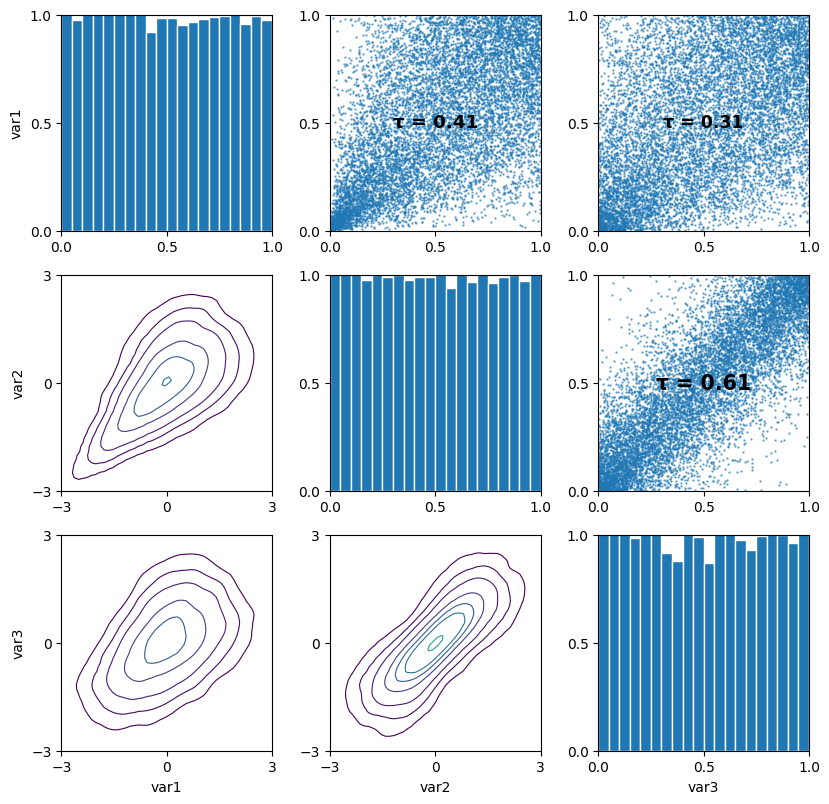

In [96]:
# simulate
u_sim = cop.simulate(n=10000)

# Visualize the simulated pair-copula data
pv.pairs_copula_data(u_sim, scatter_size=0.5)

In [97]:
# back-transform to original scale
x_sim = np.column_stack([
    np.quantile(x[:, i], u_sim[:, i])
    for i in range(d)
])

# check
print("x shape:", x.shape)
print("u_sim shape:", u_sim.shape)
print("x_sim shape:", x_sim.shape)

obs_mean = np.mean(x, axis=0)
sim_mean = np.mean(x_sim, axis=0)

print("Observed mean:", dict(zip(vars_, obs_mean)))
print("Simulated mean:", dict(zip(vars_, sim_mean)))

x shape: (24, 3)
u_sim shape: (10000, 3)
x_sim shape: (10000, 3)
Observed mean: {'tot_precip': np.float64(71.64583333333333), 'vmax_gust': np.float64(17.91881771582747), 'gust_dur': np.float64(223.75)}
Simulated mean: {'tot_precip': np.float64(70.32702135650972), 'vmax_gust': np.float64(16.853482622466384), 'gust_dur': np.float64(201.87371779161296)}


## Build the joint probability grid on the original scale

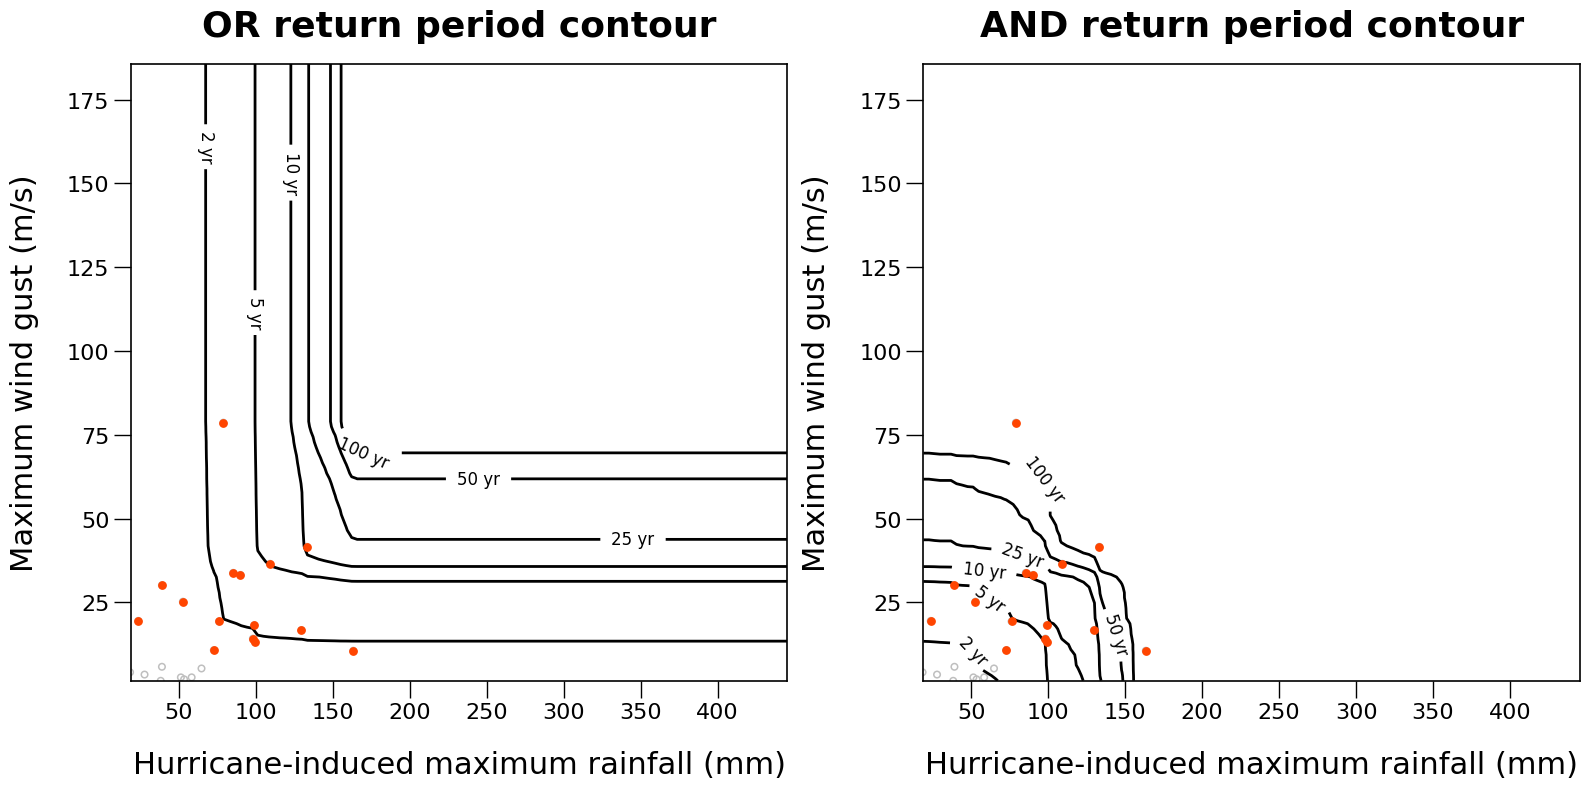

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare observed data on original scale
vars_2d = ["tot_precip", "vmax_gust"]

obs_df = (
    df[vars_2d]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

obs = obs_df.to_numpy()

rain_obs = obs[:, 0]   # mm
gust_obs = obs[:, 1]   # m/s


rain_sim = x_sim[:, 0]
gust_sim = x_sim[:, 1]


events_per_year = 1.0

# Build return period grids
def compute_return_period_surfaces(
    rain_sim,
    gust_sim,
    rain_grid,
    gust_grid,
    events_per_year=1.0
):
    """
    Compute OR and AND return period surfaces from simulated data.

    OR exceedance:
        P(R > r or G > g)

    AND exceedance:
        P(R > r and G > g)

    Return period:
        T = 1 / (events_per_year * p)
    """
    T_or = np.full((len(gust_grid), len(rain_grid)), np.nan)
    T_and = np.full((len(gust_grid), len(rain_grid)), np.nan)

    for i, g in enumerate(gust_grid):
        for j, r in enumerate(rain_grid):
            p_or = np.mean((rain_sim > r) | (gust_sim > g))
            p_and = np.mean((rain_sim > r) & (gust_sim > g))

            if p_or > 0:
                T_or[i, j] = 1.0 / (events_per_year * p_or)

            if p_and > 0:
                T_and[i, j] = 1.0 / (events_per_year * p_and)

    return T_or, T_and


# Grids on original scale
rain_grid = np.linspace(
    np.quantile(rain_sim, 0.05),
    np.quantile(rain_sim*3, 0.98),
    120
)

gust_grid = np.linspace(
    np.quantile(gust_sim, 0.05),
    np.quantile(gust_sim*3, 0.98),
    120
)

T_or, T_and = compute_return_period_surfaces(
    rain_sim=rain_sim,
    gust_sim=gust_sim,
    rain_grid=rain_grid,
    gust_grid=gust_grid,
    events_per_year=events_per_year
)



# Plot OR and AND return period contours
def plot_return_period_contours(
    rain_obs,
    gust_obs,
    rain_grid,
    gust_grid,
    T_or,
    T_and,
    contour_levels=(2, 5, 10, 25, 50, 100),
    figsize=(16, 8)
):
    Rg, Gg = np.meshgrid(rain_grid, gust_grid)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    panels = [
        (axes[0], T_or, "OR return period contour"),
        (axes[1], T_and, "AND return period contour"),
    ]

    for ax, Tsurf, title in panels:
        # background observations
        ax.scatter(
            rain_obs, gust_obs,
            s=22,
            facecolors="none",
            edgecolors="#bfbfbf",
            linewidths=1.1
        )

        # contour lines
        cs = ax.contour(
            Rg, Gg, Tsurf,
            levels=contour_levels,
            colors="black",
            linewidths=2
        )

        # labels like "2 yr", "5 yr"
        fmt = {lev: f"{int(lev)} yr" for lev in contour_levels}
        ax.clabel(cs, inline=True, fmt=fmt, fontsize=12)

        # highlight largest observed events in red
        score = rain_obs / np.nanpercentile(rain_obs, 90) + gust_obs / np.nanpercentile(gust_obs, 90)
        idx = np.argsort(score)[-15:]
        ax.scatter(
            rain_obs[idx], gust_obs[idx],
            s=28, color="orangered", zorder=3
        )

        ax.set_title(title, fontsize=26, fontweight="bold", pad=20)
        ax.set_xlabel("Hurricane-induced maximum rainfall (mm)", fontsize=22, labelpad=20)
        ax.set_ylabel("Maximum wind gust (m/s)", fontsize=22, labelpad=20)

        ax.tick_params(axis="both", labelsize=16, length=12, width=1)
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

        ax.set_xlim(rain_grid.min(), rain_grid.max())
        ax.set_ylim(gust_grid.min(), gust_grid.max())

    plt.tight_layout()
    plt.show()


plot_return_period_contours(
    rain_obs=rain_obs,
    gust_obs=gust_obs,
    rain_grid=rain_grid,
    gust_grid=gust_grid,
    T_or=T_or,
    T_and=T_and,
    contour_levels=(2, 5, 10, 25, 50, 100)
)

In [99]:
import numpy as np
import pandas as pd

# ============================================================
# 1. INPUT
#    x_sim columns:
#    0 = tot_precip (mm)
#    1 = vmax_gust (m/s)
#    2 = gust_dur (minutes)
# ============================================================

rain_sim = x_sim[:, 0]
gust_sim = x_sim[:, 1]
dur_sim  = x_sim[:, 2]

# ============================================================
# 2. SET EVENT RATE
#    IMPORTANT: adjust this correctly
# ============================================================
events_per_year = 1.0
# Example for event-based data:
# events_per_year = len(df) / number_of_years

# ============================================================
# 3. MARGINAL RETURN PERIODS TO EVALUATE
# ============================================================
marginal_rps = np.array([2, 5, 10, 20, 50, 100, 200], dtype=float)

# ============================================================
# 4. FUNCTION TO COMPUTE TRIVARIATE AND / OR RETURN PERIODS
# ============================================================
def compute_trivariate_joint_return_periods(
    rain_sim,
    gust_sim,
    dur_sim,
    marginal_rps,
    events_per_year=1.0
):
    """
    For each marginal return period Tm:
      1. find the corresponding marginal thresholds
      2. compute trivariate AND and OR exceedance probabilities
      3. convert to joint return periods

    Returns a DataFrame.
    """

    results = []

    for Tm in marginal_rps:
        # Per-event exceedance probability corresponding to marginal RP
        p_event = 1.0 / (events_per_year * Tm)

        # Guard against impossible probabilities when lambda is small
        if p_event >= 1:
            raise ValueError(
                f"Per-event exceedance probability is >= 1 for Tm={Tm}. "
                "Check events_per_year."
            )

        # Marginal thresholds on original scale
        r_thr = np.quantile(rain_sim, 1.0 - p_event)
        g_thr = np.quantile(gust_sim, 1.0 - p_event)
        d_thr = np.quantile(dur_sim,  1.0 - p_event)

        # Joint exceedance probabilities
        p_and = np.mean(
            (rain_sim > r_thr) &
            (gust_sim > g_thr) &
            (dur_sim  > d_thr)
        )

        p_or = np.mean(
            (rain_sim > r_thr) |
            (gust_sim > g_thr) |
            (dur_sim  > d_thr)
        )

        # Joint return periods
        T_and = np.inf if p_and == 0 else 1.0 / (events_per_year * p_and)
        T_or  = np.inf if p_or  == 0 else 1.0 / (events_per_year * p_or)

        results.append({
            "Marginal_RP_year": Tm,
            "Rain_threshold_mm": r_thr,
            "Gust_threshold_mps": g_thr,
            "Duration_threshold_min": d_thr,
            "p_AND": p_and,
            "p_OR": p_or,
            "T_AND_year": T_and,
            "T_OR_year": T_or
        })

    return pd.DataFrame(results)

# ============================================================
# 5. RUN
# ============================================================
rp_table = compute_trivariate_joint_return_periods(
    rain_sim=rain_sim,
    gust_sim=gust_sim,
    dur_sim=dur_sim,
    marginal_rps=marginal_rps,
    events_per_year=events_per_year
)

rp_table.round(2)

,Marginal_RP_year,Rain_threshold_mm,Gust_threshold_mps,Duration_threshold_min,p_AND,p_OR,T_AND_year,T_OR_year
0,2.0,67.64,13.57,0.00,0.21,0.66,4.78,1.52
1,5.0,99.25,31.29,506.91,0.05,0.38,21.69,2.64
2,10.0,122.80,35.69,767.40,0.01,0.23,126.58,4.42
3,20.0,132.56,40.94,1037.63,0.00,0.13,714.29,7.81
4,50.0,148.48,61.91,1401.56,0.00,0.06,10000.00,17.89
5,100.0,155.65,69.63,1522.11,0.00,0.03,inf,34.36
6,200.0,159.05,74.18,1579.06,0.00,0.01,inf,68.03


In [101]:
import itertools
import numpy as np
import pandas as pd

def compute_trivariate_joint_return_period_grid(
    rain_sim,
    gust_sim,
    dur_sim,
    rps,
    events_per_year=1.0
):
    rows = []

    for Tr, Tg, Td in itertools.product(rps, rps, rps):
        p_r = 1.0 / (events_per_year * Tr)
        p_g = 1.0 / (events_per_year * Tg)
        p_d = 1.0 / (events_per_year * Td)

        if max(p_r, p_g, p_d) >= 1:
            raise ValueError("Check events_per_year. At least one per-event exceedance probability is >= 1.")

        r_thr = np.quantile(rain_sim, 1.0 - p_r)
        g_thr = np.quantile(gust_sim, 1.0 - p_g)
        d_thr = np.quantile(dur_sim,  1.0 - p_d)

        p_and = np.mean(
            (rain_sim > r_thr) &
            (gust_sim > g_thr) &
            (dur_sim  > d_thr)
        )

        p_or = np.mean(
            (rain_sim > r_thr) |
            (gust_sim > g_thr) |
            (dur_sim  > d_thr)
        )

        T_and = np.inf if p_and == 0 else 1.0 / (events_per_year * p_and)
        T_or  = np.inf if p_or  == 0 else 1.0 / (events_per_year * p_or)

        rows.append({
            "RP_rain_year": Tr,
            "RP_gust_year": Tg,
            "RP_dur_year": Td,
            "Rain_threshold_mm": r_thr,
            "Gust_threshold_mps": g_thr,
            "Duration_threshold_min": d_thr,
            "p_AND": p_and,
            "p_OR": p_or,
            "T_AND_year": T_and,
            "T_OR_year": T_or
        })

    return pd.DataFrame(rows)

rp_grid = compute_trivariate_joint_return_period_grid(
    rain_sim=rain_sim,
    gust_sim=gust_sim,
    dur_sim=dur_sim,
    rps=np.array([2, 5, 10, 20, 50, 100, 200], dtype=float),
    events_per_year=events_per_year
)

print("Number of combinations:", len(rp_grid))
rp_grid.head()

Number of combinations: 343


,RP_rain_year,RP_gust_year,RP_dur_year,Rain_threshold_mm,Gust_threshold_mps,Duration_threshold_min,p_AND,p_OR,T_AND_year,T_OR_year
0,2.0,2.0,2.0,67.644581,13.566138,0.000000,0.2091,0.6571,4.782401,1.521838
1,2.0,2.0,5.0,67.644581,13.566138,506.914199,0.1433,0.6506,6.978367,1.537043
2,2.0,2.0,10.0,67.644581,13.566138,767.398755,0.0745,0.6475,13.422819,1.544402
3,2.0,2.0,20.0,67.644581,13.566138,1037.633043,0.0367,0.6468,27.247956,1.546073
4,2.0,2.0,50.0,67.644581,13.566138,1401.556378,0.0149,0.6464,67.114094,1.547030


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. INPUT
#    x_sim columns:
#    0 = tot_precip (mm)
#    1 = vmax_gust (m/s)
#    2 = gust_dur (minutes)
# ============================================================
rain_sim = x_sim[:, 0]
gust_sim = x_sim[:, 1]
dur_sim  = x_sim[:, 2]

# ============================================================
# 2. EVENT RATE
#    If these are annual maxima, keep 1.0
#    Otherwise replace with average number of events per year
# ============================================================
events_per_year = 1.0

# ============================================================
# 3. SELECTED MARGINAL RETURN PERIODS
# ============================================================
rp_values = np.array([2, 5, 10, 20, 50, 100, 200], dtype=float)

# Fixed duration marginal return period for the heatmap
fixed_duration_rp = 20.0


# ============================================================
# 4. COMPUTE HEATMAP MATRIX
# ============================================================
def trivariate_and_return_period_heatmap(
    rain_sim,
    gust_sim,
    dur_sim,
    rp_rain_values,
    rp_gust_values,
    fixed_duration_rp,
    events_per_year=1.0
):
    """
    Returns a DataFrame whose rows are gust marginal RPs and columns
    are rainfall marginal RPs. Each cell is the trivariate AND return period.

    AND probability:
        P(R > r_thr, G > g_thr, D > d_thr)

    Joint return period:
        1 / (events_per_year * p_and)
    """

    # Fixed duration threshold
    p_d = 1.0 / (events_per_year * fixed_duration_rp)
    if p_d >= 1:
        raise ValueError("fixed_duration_rp is too small relative to events_per_year.")

    d_thr = np.quantile(dur_sim, 1.0 - p_d)

    T_and_mat = np.full((len(rp_gust_values), len(rp_rain_values)), np.nan)

    rain_thr_mat = np.full_like(T_and_mat, np.nan, dtype=float)
    gust_thr_mat = np.full_like(T_and_mat, np.nan, dtype=float)

    for i, Tg in enumerate(rp_gust_values):
        p_g = 1.0 / (events_per_year * Tg)
        if p_g >= 1:
            raise ValueError(f"Gust RP {Tg} gives per-event exceedance probability >= 1.")

        g_thr = np.quantile(gust_sim, 1.0 - p_g)

        for j, Tr in enumerate(rp_rain_values):
            p_r = 1.0 / (events_per_year * Tr)
            if p_r >= 1:
                raise ValueError(f"Rain RP {Tr} gives per-event exceedance probability >= 1.")

            r_thr = np.quantile(rain_sim, 1.0 - p_r)

            p_and = np.mean(
                (rain_sim > r_thr) &
                (gust_sim > g_thr) &
                (dur_sim  > d_thr)
            )

            T_and = np.inf if p_and == 0 else 1.0 / (events_per_year * p_and)

            T_and_mat[i, j] = T_and
            rain_thr_mat[i, j] = r_thr
            gust_thr_mat[i, j] = g_thr

    T_and_df = pd.DataFrame(
        T_and_mat,
        index=[f"{int(v)}" for v in rp_gust_values],
        columns=[f"{int(v)}" for v in rp_rain_values]
    )

    rain_thr_df = pd.DataFrame(
        rain_thr_mat,
        index=[f"{int(v)}" for v in rp_gust_values],
        columns=[f"{int(v)}" for v in rp_rain_values]
    )

    gust_thr_df = pd.DataFrame(
        gust_thr_mat,
        index=[f"{int(v)}" for v in rp_gust_values],
        columns=[f"{int(v)}" for v in rp_rain_values]
    )

    return T_and_df, rain_thr_df, gust_thr_df, d_thr


T_and_df, rain_thr_df, gust_thr_df, d_thr = trivariate_and_return_period_heatmap(
    rain_sim=rain_sim,
    gust_sim=gust_sim,
    dur_sim=dur_sim,
    rp_rain_values=rp_values,
    rp_gust_values=rp_values,
    fixed_duration_rp=fixed_duration_rp,
    events_per_year=events_per_year
)

print("Fixed duration RP (years):", fixed_duration_rp)
print("Corresponding duration threshold (minutes):", round(d_thr, 2))
print(T_and_df.round(2))

Fixed duration RP (years): 20.0
Corresponding duration threshold (minutes): 1037.63
          2        5       10       20        50       100      200
2     27.25    58.48   116.28   238.10    588.24   1428.57   2500.0
5     34.60    73.53   149.25   285.71    714.29   2000.00   5000.0
10    49.26   103.09   227.27   476.19   1111.11   2000.00   5000.0
20    86.21   169.49   416.67   714.29   1666.67   2500.00   5000.0
50   200.00   384.62   769.23  1250.00   5000.00   5000.00  10000.0
100  333.33   714.29  1250.00  1666.67  10000.00  10000.00  10000.0
200  588.24  1428.57  1666.67  2000.00  10000.00  10000.00  10000.0


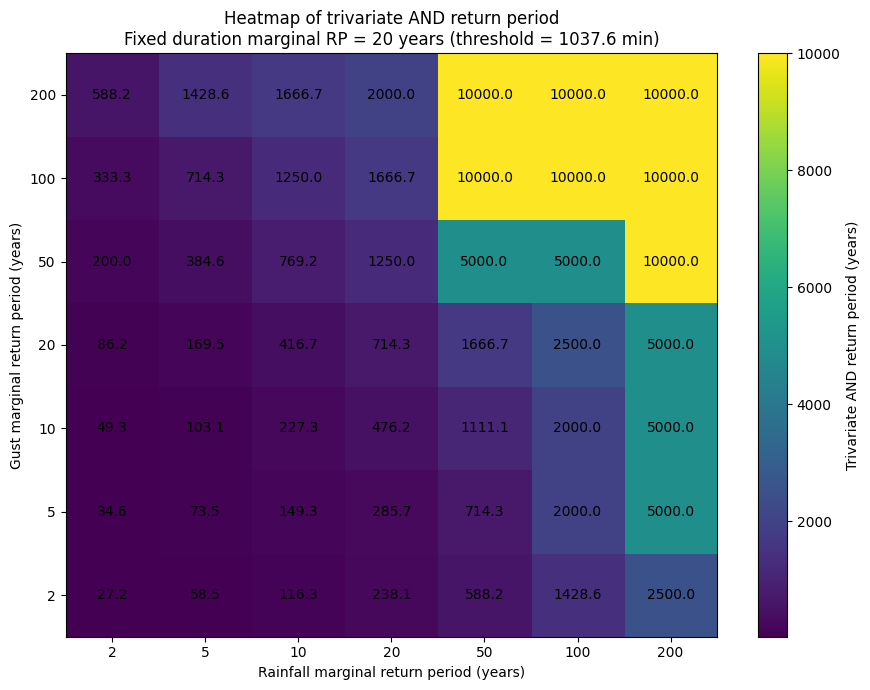

In [103]:
# ============================================================
# 5. PLOT HEATMAP
# ============================================================
def plot_trivariate_and_heatmap(
    T_and_df,
    fixed_duration_rp,
    d_thr,
    figsize=(8, 6),
    annotate=True
):
    fig, ax = plt.subplots(figsize=figsize)

    mat = T_and_df.to_numpy(dtype=float)

    # Optional: cap infinite values for plotting
    finite_vals = mat[np.isfinite(mat)]
    vmax = np.nanmax(finite_vals) if finite_vals.size > 0 else 1.0
    mat_plot = np.where(np.isfinite(mat), mat, vmax)

    im = ax.imshow(mat_plot, origin="lower", aspect="auto")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Trivariate AND return period (years)")

    ax.set_xticks(np.arange(T_and_df.shape[1]))
    ax.set_yticks(np.arange(T_and_df.shape[0]))

    ax.set_xticklabels(T_and_df.columns)
    ax.set_yticklabels(T_and_df.index)

    ax.set_xlabel("Rainfall marginal return period (years)")
    ax.set_ylabel("Gust marginal return period (years)")
    ax.set_title(
        "Heatmap of trivariate AND return period\n"
        f"Fixed duration marginal RP = {fixed_duration_rp:.0f} years "
        f"(threshold = {d_thr:.1f} min)"
    )

    if annotate:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                txt = "Inf" if not np.isfinite(val) else f"{val:.1f}"
                ax.text(j, i, txt, ha="center", va="center")

    plt.tight_layout()
    plt.show()


plot_trivariate_and_heatmap(
    T_and_df=T_and_df,
    fixed_duration_rp=fixed_duration_rp,
    d_thr=d_thr,
    figsize=(9, 7),
    annotate=True
)

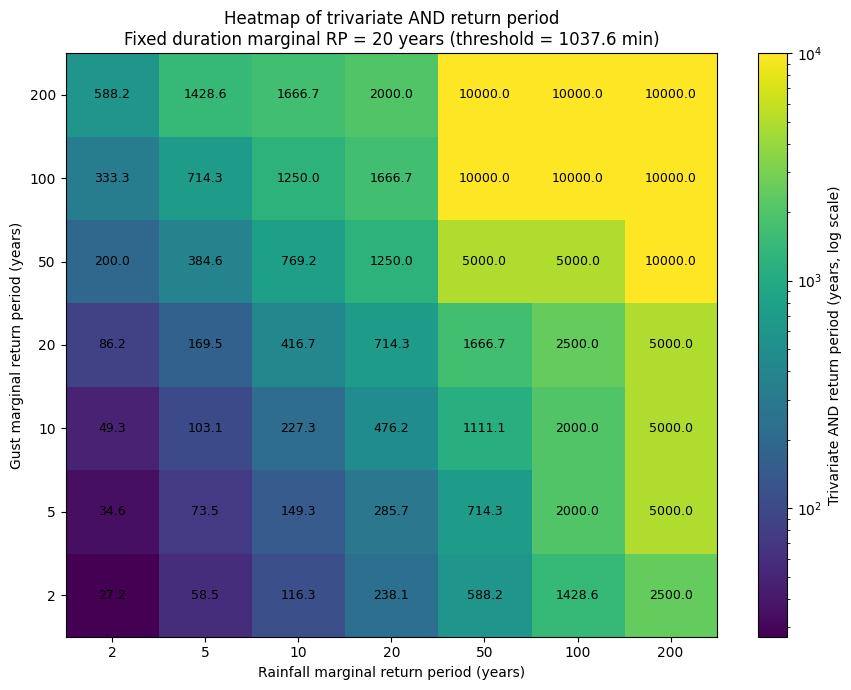

In [104]:
from matplotlib.colors import LogNorm

def plot_trivariate_and_heatmap_log(
    T_and_df,
    fixed_duration_rp,
    d_thr,
    figsize=(8, 6),
    annotate=True
):
    fig, ax = plt.subplots(figsize=figsize)

    mat = T_and_df.to_numpy(dtype=float)

    finite_vals = mat[np.isfinite(mat) & (mat > 0)]
    if finite_vals.size == 0:
        raise ValueError("No positive finite values available for log-scaled heatmap.")

    vmin = np.nanmin(finite_vals)
    vmax = np.nanmax(finite_vals)

    mat_plot = np.where(np.isfinite(mat), mat, vmax)

    im = ax.imshow(
        mat_plot,
        origin="lower",
        aspect="auto",
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Trivariate AND return period (years, log scale)")

    ax.set_xticks(np.arange(T_and_df.shape[1]))
    ax.set_yticks(np.arange(T_and_df.shape[0]))
    ax.set_xticklabels(T_and_df.columns)
    ax.set_yticklabels(T_and_df.index)

    ax.set_xlabel("Rainfall marginal return period (years)")
    ax.set_ylabel("Gust marginal return period (years)")
    ax.set_title(
        "Heatmap of trivariate AND return period\n"
        f"Fixed duration marginal RP = {fixed_duration_rp:.0f} years "
        f"(threshold = {d_thr:.1f} min)"
    )

    if annotate:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                txt = "Inf" if not np.isfinite(val) else f"{val:.1f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()


plot_trivariate_and_heatmap_log(
    T_and_df=T_and_df,
    fixed_duration_rp=fixed_duration_rp,
    d_thr=d_thr,
    figsize=(9, 7),
    annotate=True
)

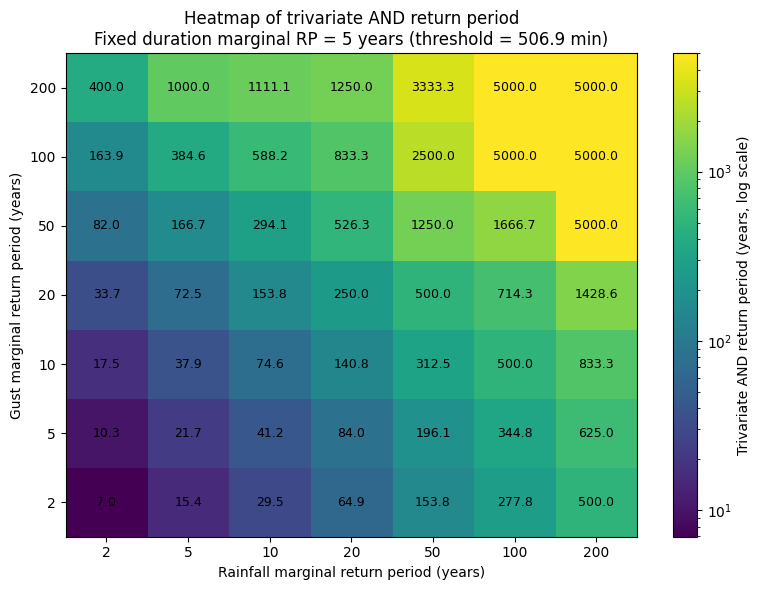

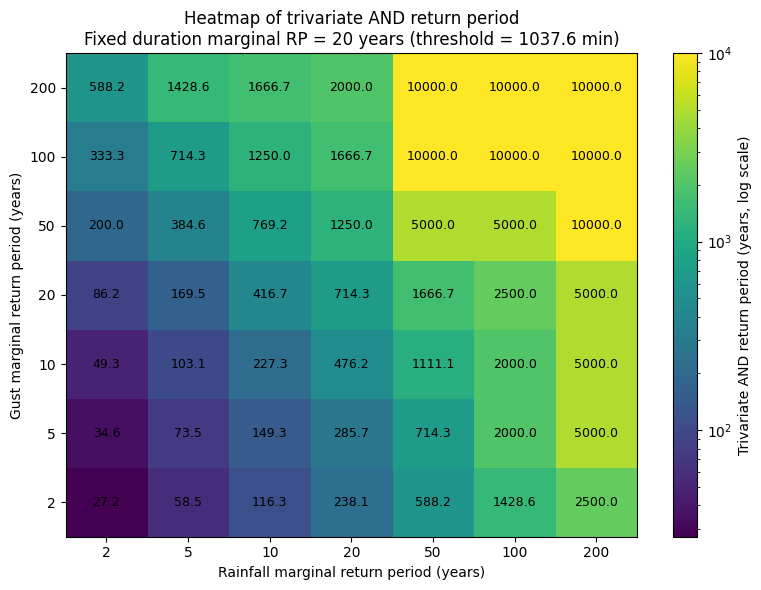

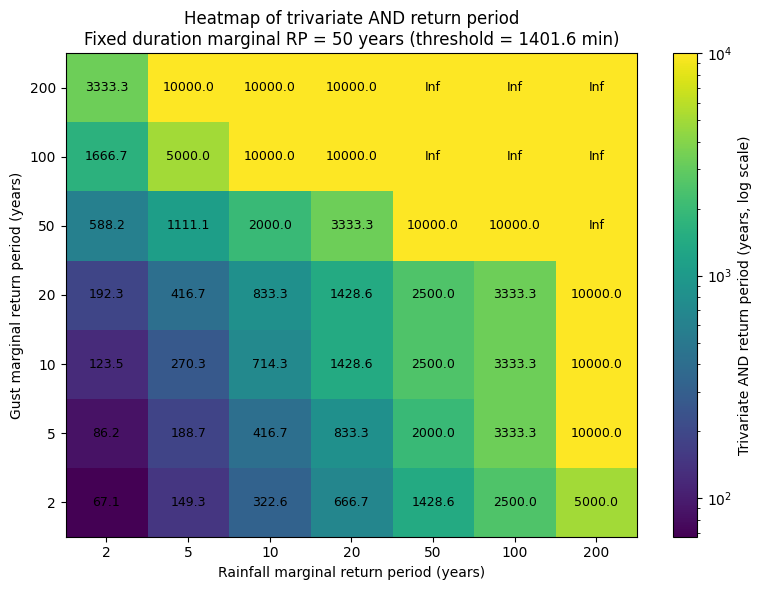

In [105]:
fixed_duration_rps = [5, 20, 50]

for fd in fixed_duration_rps:
    T_and_df, _, _, d_thr = trivariate_and_return_period_heatmap(
        rain_sim=rain_sim,
        gust_sim=gust_sim,
        dur_sim=dur_sim,
        rp_rain_values=rp_values,
        rp_gust_values=rp_values,
        fixed_duration_rp=fd,
        events_per_year=events_per_year
    )

    plot_trivariate_and_heatmap_log(
        T_and_df=T_and_df,
        fixed_duration_rp=fd,
        d_thr=d_thr,
        figsize=(8, 6),
        annotate=True
    )

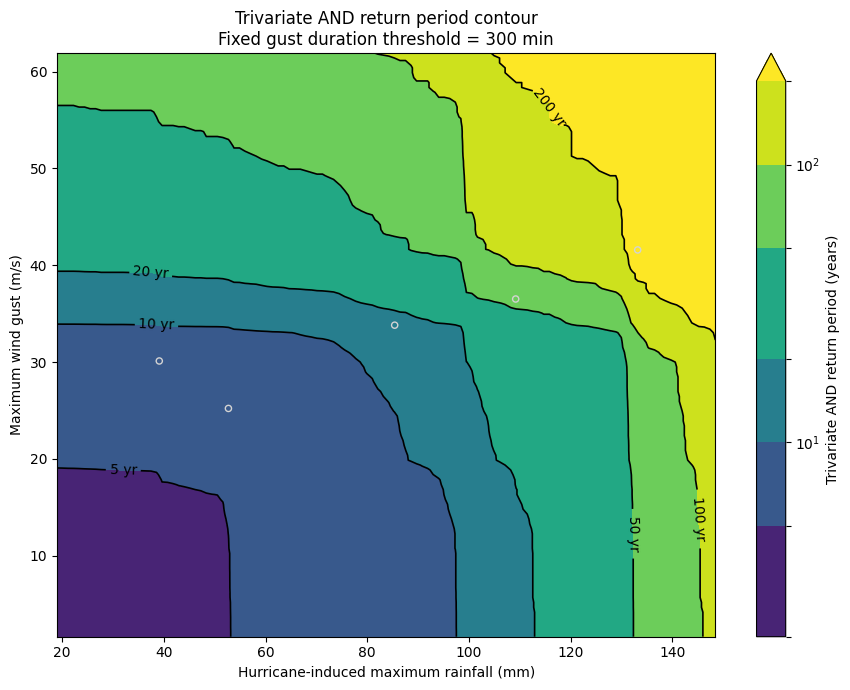

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# 1. INPUT
# ============================================================
rain_sim = x_sim[:, 0]   # mm
gust_sim = x_sim[:, 1]   # m/s
dur_sim  = x_sim[:, 2]   # minutes

# Optional observed data for overlay
obs_df = (
    df[["tot_precip", "vmax_gust", "gust_dur"]]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

rain_obs = obs_df["tot_precip"].to_numpy()
gust_obs = obs_df["vmax_gust"].to_numpy()
dur_obs  = obs_df["gust_dur"].to_numpy()

# ============================================================
# 2. EVENT RATE
#    Set this correctly
# ============================================================
events_per_year = 1.0
# Example for event-based observations:
# events_per_year = len(obs_df) / number_of_years


# ============================================================
# 3. FUNCTION TO COMPUTE 2D RETURN PERIOD SURFACE
#    WITH FIXED DURATION THRESHOLD
# ============================================================
def compute_trivariate_return_period_surface_fixed_duration(
    rain_sim,
    gust_sim,
    dur_sim,
    rain_grid,
    gust_grid,
    dur_threshold,
    events_per_year=1.0,
    mode="AND"
):
    """
    Compute a 2D return period surface in rainfall-gust space,
    with duration fixed as an exceedance threshold D > dur_threshold.

    mode = "AND" or "OR"

    AND:
        P(R > r, G > g, D > d0)

    OR:
        P(R > r or G > g or D > d0)
    """
    T = np.full((len(gust_grid), len(rain_grid)), np.nan)

    for i, g in enumerate(gust_grid):
        for j, r in enumerate(rain_grid):
            if mode.upper() == "AND":
                p = np.mean(
                    (rain_sim > r) &
                    (gust_sim > g) &
                    (dur_sim  > dur_threshold)
                )
            elif mode.upper() == "OR":
                p = np.mean(
                    (rain_sim > r) |
                    (gust_sim > g) |
                    (dur_sim  > dur_threshold)
                )
            else:
                raise ValueError("mode must be 'AND' or 'OR'")

            if p > 0:
                T[i, j] = 1.0 / (events_per_year * p)

    return T


# ============================================================
# 4. CHOOSE ORIGINAL-SCALE AXIS RANGES
# ============================================================
rain_grid = np.linspace(
    np.quantile(rain_sim, 0.05),
    np.quantile(rain_sim, 0.98),
    120
)

gust_grid = np.linspace(
    np.quantile(gust_sim, 0.05),
    np.quantile(gust_sim, 0.98),
    120
)

Rg, Gg = np.meshgrid(rain_grid, gust_grid)


# ============================================================
# 5. SET FIXED DURATION THRESHOLD
# ============================================================
dur_threshold = 300.0   # minutes


# ============================================================
# 6. COMPUTE AND RETURN PERIOD SURFACE
# ============================================================
T_and = compute_trivariate_return_period_surface_fixed_duration(
    rain_sim=rain_sim,
    gust_sim=gust_sim,
    dur_sim=dur_sim,
    rain_grid=rain_grid,
    gust_grid=gust_grid,
    dur_threshold=dur_threshold,
    events_per_year=events_per_year,
    mode="AND"
)


# ============================================================
# 7. PLOT AS CONTOUR FIGURE
# ============================================================
def plot_trivariate_and_contour_fixed_duration(
    rain_grid,
    gust_grid,
    T_and,
    dur_threshold,
    rain_obs=None,
    gust_obs=None,
    dur_obs=None,
    overlay_obs=True,
    contour_levels=(2, 5, 10, 20, 50, 100, 200),
    use_log_color=True
):
    fig, ax = plt.subplots(figsize=(9, 7))

    finite_vals = T_and[np.isfinite(T_and) & (T_and > 0)]
    if finite_vals.size == 0:
        raise ValueError("No positive finite return period values found.")

    if use_log_color:
        cf = ax.contourf(
            rain_grid,
            gust_grid,
            T_and,
            levels=contour_levels,
            norm=LogNorm(vmin=min(contour_levels), vmax=max(contour_levels)),
            extend="max"
        )
    else:
        cf = ax.contourf(
            rain_grid,
            gust_grid,
            T_and,
            levels=contour_levels,
            extend="max"
        )

    cs = ax.contour(
        rain_grid,
        gust_grid,
        T_and,
        levels=contour_levels,
        colors="black",
        linewidths=1.2
    )

    fmt = {lev: f"{int(lev)} yr" for lev in contour_levels}
    ax.clabel(cs, inline=True, fmt=fmt, fontsize=10)

    if overlay_obs and rain_obs is not None and gust_obs is not None and dur_obs is not None:
        mask = dur_obs > dur_threshold
        ax.scatter(
            rain_obs[mask],
            gust_obs[mask],
            s=20,
            facecolors="none",
            edgecolors="lightgray",
            linewidths=1.0,
            zorder=3
        )

    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label("Trivariate AND return period (years)")

    ax.set_xlabel("Hurricane-induced maximum rainfall (mm)")
    ax.set_ylabel("Maximum wind gust (m/s)")
    ax.set_title(
        f"Trivariate AND return period contour\n"
        f"Fixed gust duration threshold = {dur_threshold:.0f} min"
    )

    ax.set_xlim(rain_grid.min(), rain_grid.max())
    ax.set_ylim(gust_grid.min(), gust_grid.max())

    plt.tight_layout()
    plt.show()


plot_trivariate_and_contour_fixed_duration(
    rain_grid=rain_grid,
    gust_grid=gust_grid,
    T_and=T_and,
    dur_threshold=dur_threshold,
    rain_obs=rain_obs,
    gust_obs=gust_obs,
    dur_obs=dur_obs,
    overlay_obs=True,
    contour_levels=(2, 5, 10, 20, 50, 100, 200),
    use_log_color=True
)

In [111]:
simulated_results = pd.DataFrame(x_sim, columns=["tot_precip_mm", "vmax_gust_mps", "gust_dur_min"])
simulated_results.head()

,tot_precip_mm,vmax_gust_mps,gust_dur_min
0,55.819208,27.915137,0.000000
1,98.256201,25.524588,687.939178
2,105.471181,5.381038,416.997011
3,57.637057,2.614047,0.000000
4,57.510292,10.704584,0.000000


In [112]:
simulated_results.describe().round(2)

,tot_precip_mm,vmax_gust_mps,gust_dur_min
count,10000.00,10000.00,10000.00
mean,70.33,16.85,201.87
std,35.08,14.94,377.54
min,16.51,1.28,0.00
25%,39.10,3.87,0.00
50%,67.64,13.57,0.00
75%,98.40,26.15,234.78
max,163.38,78.47,1649.32


In [113]:
x_df["gust_dur"].unique()

array([   0, 1065,  150,  375,  690,  795,  645, 1650])

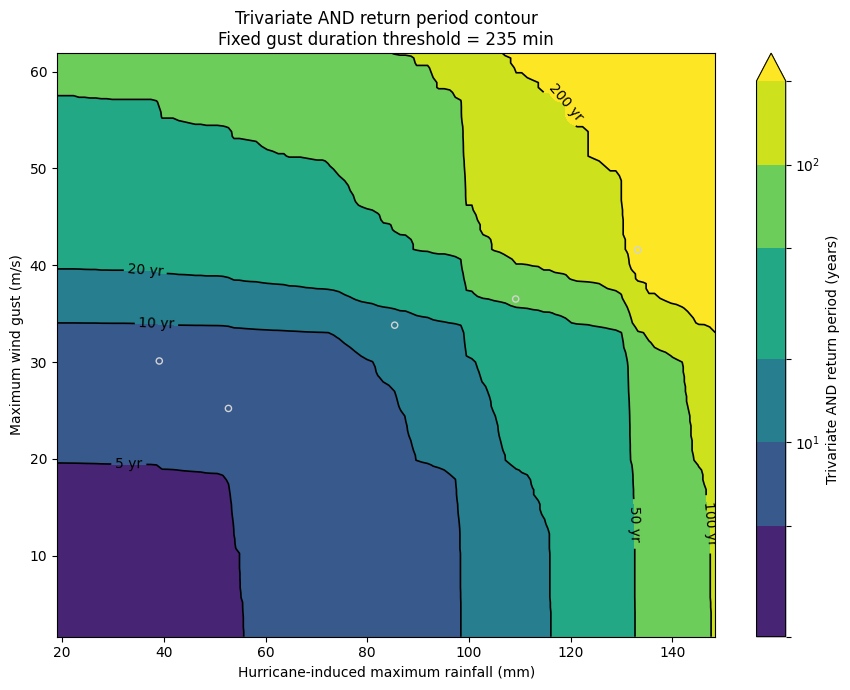

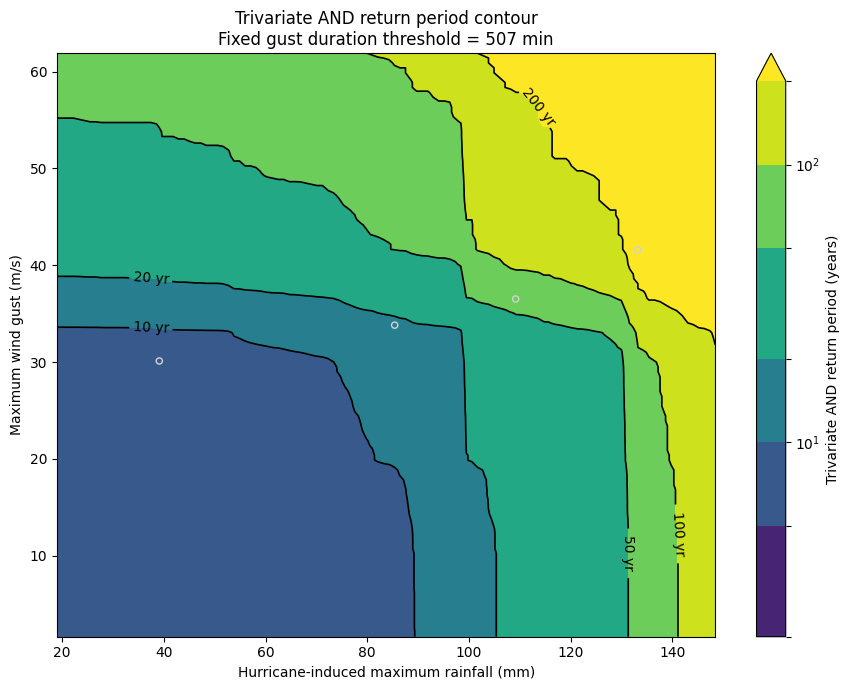

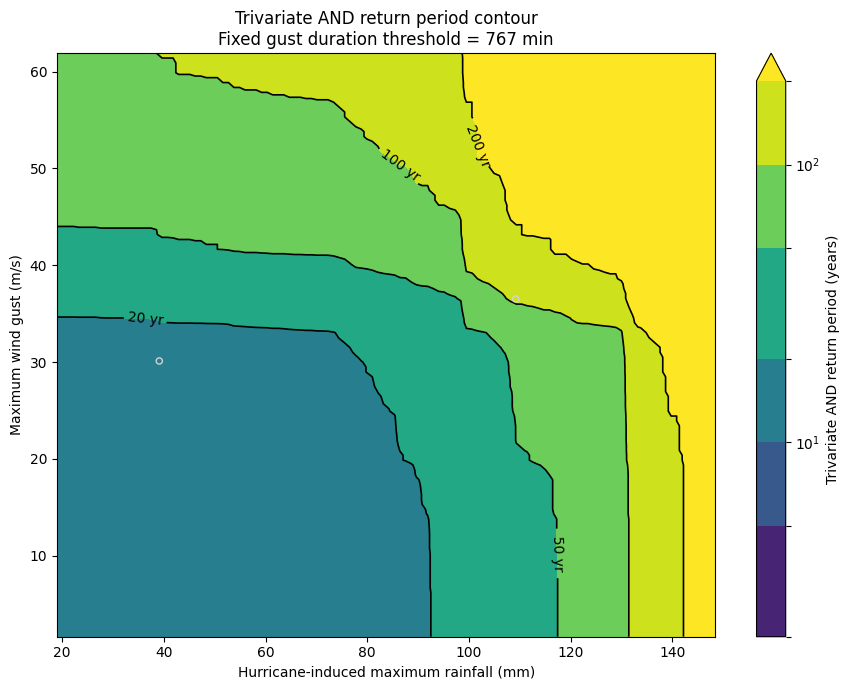

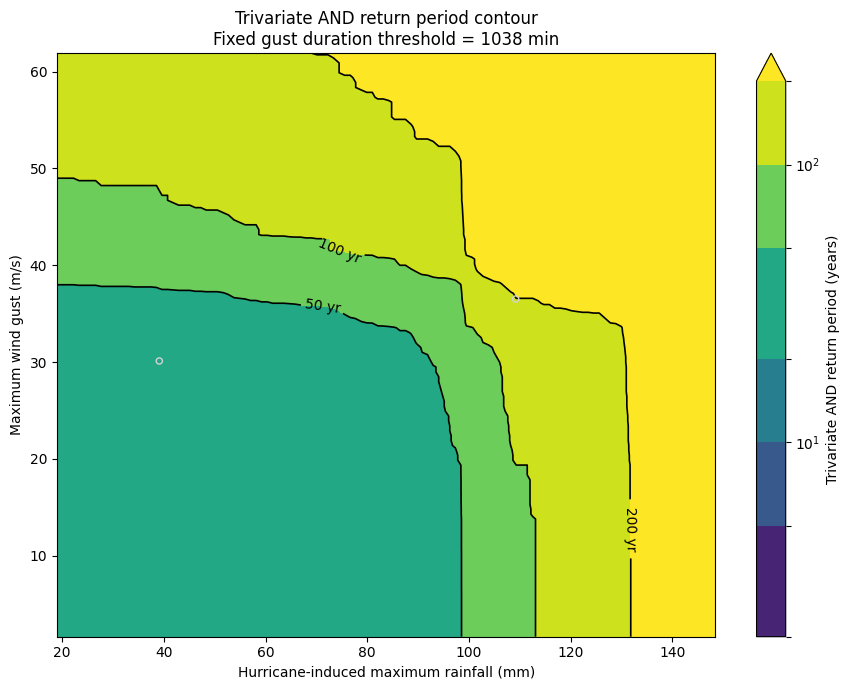

In [121]:
for d0 in np.quantile(dur_sim, [0.75, 0.8, 0.9, 0.95]):
    T_and = compute_trivariate_return_period_surface_fixed_duration(
        rain_sim=rain_sim,
        gust_sim=gust_sim,
        dur_sim=dur_sim,
        rain_grid=rain_grid,
        gust_grid=gust_grid,
        dur_threshold=d0,
        events_per_year=events_per_year,
        mode="AND"
    )

    plot_trivariate_and_contour_fixed_duration(
        rain_grid=rain_grid,
        gust_grid=gust_grid,
        T_and=T_and,
        dur_threshold=d0,
        rain_obs=rain_obs,
        gust_obs=gust_obs,
        dur_obs=dur_obs,
        overlay_obs=True,
        contour_levels=(2, 5, 10, 20, 50, 100, 200),
        use_log_color=True
    )

If:
- rainfall = 120 mm
- wind gust = 35 m/s

Then:
- In the 235 min duration panel, maybe ~50-year event
- In the 1038 min duration panel, maybe ~150–200-year event